<a href="https://colab.research.google.com/github/aedenj/faithful-cuts/blob/main/CSED504_Faithful_Cuts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os, sys

_REPO_DIR = os.path.abspath("faithful-cuts")

if not os.path.isdir(_REPO_DIR):
    !git clone https://github.com/aedenj/faithful-cuts.git

if _REPO_DIR not in sys.path:
    sys.path.insert(0, _REPO_DIR)


Cloning into 'faithful-cuts'...
remote: Enumerating objects: 130, done.
remote: Counting objects: 100% (130/130), done.
remote: Compressing objects: 100% (105/105), done.
remote: Total 130 (delta 66), reused 63 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (130/130), 2.63 MiB | 6.26 MiB/s, done.
Resolving deltas: 100% (66/66), done.


In [2]:
!pip install -q -U qwen-omni-utils outlines pydantic networkx openai


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.7/114.7 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 104.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 87.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.0 MB/s eta 0:00:00


# Setup

In [3]:
import requests
import gc
import json
import re
from pathlib import Path

from pydantic import BaseModel, Field, ConfigDict

import outlines
from outlines.inputs import Chat, Video

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers.video_utils import load_video
import numpy as np

import pandas as pd
from moviepy.video.io.VideoFileClip import VideoFileClip

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)


In [4]:
def cleanup_gpu():
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

### Download Data

In [5]:
BBC_ROOT = Path("bbc").resolve()
BBC_FOLDER_ID = "1SbqWxfZ6YHBNAIFwtraJZXl1K3qNq3M_"

EXP_RUNS_PATH = BBC_ROOT / "runs"
CURRENT_EXP_FOLDER = "qwen35-gpt4o"

SCENE_CACHE_PATH = Path('/content/bbc/runs') / CURRENT_EXP_FOLDER / 'scene_descriptions.csv'
FACTS_CACHE_PATH = Path('/content/bbc/runs') / CURRENT_EXP_FOLDER / 'scene_facts.csv'
QUESTIONS_CACHE_PATH = Path('/content/bbc/runs') / CURRENT_EXP_FOLDER / 'scene_questions.csv'
GRAPH_CACHE_PATH = Path('/content/bbc/runs') / CURRENT_EXP_FOLDER / 'scene_dependencies.csv'

In [6]:
from google.colab import auth
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload

auth.authenticate_user()
_drive = build("drive", "v3")

def _list_children(folder_id):
    items, page_token = [], None
    while True:
        resp = (
            _drive.files()
            .list(
                q=f"'{folder_id}' in parents and trashed=false",
                fields="nextPageToken, files(id, name, mimeType)",
                pageSize=1000,
                pageToken=page_token,
                supportsAllDrives=True,
                includeItemsFromAllDrives=True,
            )
            .execute()
        )
        items.extend(resp.get("files", []))
        page_token = resp.get("nextPageToken")
        if not page_token:
            return items

def _download_bbc_tree(folder_id, dest):
    dest = Path(dest)
    dest.mkdir(parents=True, exist_ok=True)
    for item in _list_children(folder_id):
        # Skip anything that isn't part of the BBC dataset (e.g. models/).
        if item["mimeType"] == "application/vnd.google-apps.folder" and item["name"] == "models":
            continue

        target = dest / item["name"]
        if item["mimeType"] == "application/vnd.google-apps.folder":
            _download_bbc_tree(item["id"], target)
        elif not target.exists():
            request = _drive.files().get_media(fileId=item["id"], supportsAllDrives=True)
            with open(target, "wb") as fh:
                downloader = MediaIoBaseDownload(fh, request, chunksize=64 * 1024 * 1024)
                done = False
                while not done:
                    _, done = downloader.next_chunk()
            print(f"  {target.relative_to(BBC_ROOT)}")

#### Download Runs

Downloads all previous experiments with this notebook.

In [7]:
runs_folder_id = None
for item in _list_children(BBC_FOLDER_ID):
    if item["name"] == "runs" and item["mimeType"] == "application/vnd.google-apps.folder":
        runs_folder_id = item["id"]
        break

if runs_folder_id:
    print(f"Downloading experiment runs to {EXP_RUNS_PATH} (Drive API)...")
    _download_bbc_tree(runs_folder_id, EXP_RUNS_PATH)
    print("Experiment runs download complete.")
else:
    print(f"Could not find 'runs' folder within BBC_FOLDER_ID: {BBC_FOLDER_ID}")

  runs/qwen35-gpt4o/scene_questions.csv
  runs/qwen35-gpt4o/scene_dependencies.csv
  runs/qwen35-gpt4o/scene_facts.csv
  runs/qwen35-gpt4o/scene_descriptions.csv
Experiment runs download complete.


#### Download BBC Dataset - MP4's & Ground Truth

This can be skipped if ya don't need it, which is the case when working with a specific experiment run

In [8]:
bbc_movies = [f"bbc_{n:02d}" for n in range(1, 12)]

def _bbc_assets_present():
    gt_ok = all(
        (BBC_ROOT / "GT" / f"{m}_shots.csv").exists()
        and (BBC_ROOT / "GT" / f"{m}_scenes.csv").exists()  # Corrected line
        for m in bbc_movies
    )
    videos_ok = all((BBC_ROOT / f"{m}.mp4").exists() for m in bbc_movies)
    return gt_ok and videos_ok


if not _bbc_assets_present():
    print(f"Downloading BBC dataset (GT and MP4s) to {BBC_ROOT} (Drive API)...")

    # List all children of the main BBC folder
    bbc_items = _list_children(BBC_FOLDER_ID)

    gt_folder_id = None
    mp4_files_to_download = []

    for item in bbc_items:
        if item["name"] == "GT" and item["mimeType"] == "application/vnd.google-apps.folder":
            gt_folder_id = item["id"]
        elif item["name"].endswith(".mp4") and item["name"].startswith("bbc_"):
            mp4_files_to_download.append(item)

    # Download the GT folder
    if gt_folder_id:
        print(f"  Downloading GT folder...")
        _download_bbc_tree(gt_folder_id, BBC_ROOT / "GT")
    else:
        print("  GT folder not found within BBC_FOLDER_ID.")

    # Download individual MP4 files
    for mp4_file in mp4_files_to_download:
        target_path = BBC_ROOT / mp4_file["name"]
        if not target_path.exists():
            print(f"  Downloading {mp4_file['name']}...")
            request = _drive.files().get_media(fileId=mp4_file["id"], supportsAllDrives=True)
            with open(target_path, "wb") as fh:
                downloader = MediaIoBaseDownload(fh, request, chunksize=64 * 1024 * 1024)
                done = False
                while not done:
                    _, done = downloader.next_chunk()
            print(f"    {target_path.relative_to(BBC_ROOT)}")
        else:
            print(f"  {mp4_file['name']} already exists, skipping.")

    print("BBC dataset download (GT and MP4s) complete.")

print("BBC_ROOT =", BBC_ROOT, "| assets present:", _bbc_assets_present())

  GT/bbc_02_shots.csv
  GT/bbc_01_shots.csv.xlsx
  GT/bbc_10_shots.csv
  GT/bbc_08_shots.csv
  GT/bbc_11_scenes.csv
  GT/bbc_04_shots.csv
  GT/bbc_07_shots.csv
  GT/bbc_07_scenes.csv
  GT/bbc_01_shots.xlsx
  GT/bbc_06_scenes.csv
  GT/bbc_02_scenes.csv
  GT/bbc_03_scenes.csv
  GT/bbc_videos.csv
  GT/bbc_01_shots.csv
  GT/bbc_03_shots.csv
  GT/bbc_04_scenes.csv
  GT/bbc_09_shots.csv
  GT/bbc_10_scenes.csv
  GT/bbc_11_shots.csv
  GT/bbc_06_shots.csv
  GT/bbc_05_scenes.csv
  GT/bbc_09_scenes.csv
  GT/bbc_05_shots.csv
  GT/bbc_08_scenes.csv
  GT/bbc_01_scenes.csv
    bbc_11.mp4
    bbc_10.mp4
    bbc_06.mp4
    bbc_09.mp4
    bbc_04.mp4
    bbc_07.mp4
    bbc_05.mp4
    bbc_08.mp4
    bbc_03.mp4
    bbc_02.mp4
    bbc_01.mp4
BBC dataset download (GT and MP4s) complete.
BBC_ROOT = /content/bbc | assets present: True


# Extract Scenes

The BBC videos and GT (shots/scenes CSVs) are downloaded from a shared Google Drive folder.

In [ ]:
def extract_scenes_from_gt(movie_name, root_path):
    # Load ground truth files
    shots_df = pd.read_csv(root_path / "GT" / f"{movie_name}_shots.csv")
    scenes_df = pd.read_csv(root_path / "GT" / f"{movie_name}_scenes.csv")

    def get_col(df, possible_names):
        for name in possible_names:
            if name in df.columns: return name
        raise KeyError(f"None of {possible_names} found in {df.columns.tolist()}")

    shot_start_col = get_col(shots_df, ['begin', 'start_frame', 'start'])
    shot_end_col = get_col(shots_df, ['end', 'end_frame'])
    scene_start_col = get_col(scenes_df, ['start_shot', 'begin', 'start'])
    scene_end_col = get_col(scenes_df, ['end_shot', 'end'])

    video_path = root_path / f"{movie_name}.mp4"
    output_dir = root_path / "scenes" / movie_name
    output_dir.mkdir(parents=True, exist_ok=True)

    num_shots = len(shots_df)

    with VideoFileClip(str(video_path)) as video:
        fps = video.fps

        for idx, row in scenes_df.iterrows():
            try:
                # Adjusting for 1-based indexing in the CSV
                start_shot_idx = int(row[scene_start_col]) - 1
                end_shot_idx = int(row[scene_end_col]) - 1

                # Bounds check
                if start_shot_idx < 0 or start_shot_idx >= num_shots or \
                   end_shot_idx < 0 or end_shot_idx >= num_shots:
                    print(f"  Skipping scene {idx} in {movie_name}: indices {start_shot_idx+1}-{end_shot_idx+1} out of range (total shots: {num_shots})")
                    continue

                scene_start_frame = shots_df.iloc[start_shot_idx][shot_start_col]
                scene_end_frame = shots_df.iloc[end_shot_idx][shot_end_col]

                start_time = float(scene_start_frame) / fps
                end_time = float(scene_end_frame) / fps

                output_filename = output_dir / f"scene_{idx:03d}.mp4"
                scene_clip = video.subclip(start_time, end_time)
                scene_clip.write_videofile(str(output_filename), codec="libx264", audio_codec="aac", verbose=False, logger=None)
            except Exception as inner_e:
                print(f"  Error processing scene {idx} in {movie_name}: {inner_e}")

    print(f"Finished processing {movie_name}")

# Process all BBC movies
for movie in bbc_movies:
    try:
        extract_scenes_from_gt(movie, BBC_ROOT)
    except Exception as e:
        print(f"Could not process {movie}: {e}")

# Generate Scene Descriptions

### Model Setup

In [ ]:
from transformers import (
    AutoModelForMultimodalLM,
    AutoProcessor,
)

# SCENE_DESC_MODEL = "Qwen/Qwen3-VL-30B-A3B-Instruct"
SCENE_DESC_MODEL = "Qwen/Qwen3.5-35B-A3B"
# SCENE_DESC_MODEL = "Qwen/Qwen3-VL-8B-Instruct"

qwen_scene_desc_processor = AutoProcessor.from_pretrained(
    SCENE_DESC_MODEL
)

qwen_scene_desc_model = AutoModelForMultimodalLM.from_pretrained(
    SCENE_DESC_MODEL,
    device_map="auto",
    dtype="auto",
)

preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/7.76k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/3.54k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/1026 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

In [9]:
class SceneDescription(BaseModel):
    model_config = ConfigDict(extra="forbid")

    summary: str = Field(..., description="A concise but detailed summary of the visual scene depicted in the image or video.")

In [10]:
import pandas as pd
import numpy as np

def process_all_scenes(root_path, outlines_model, processor, limit_per_movie=None):
    """
    Processes video scenes using a pre-initialized outlines model.
    Returns a pandas DataFrame of results.
    """
    all_records = []
    scene_base = root_path / "scenes"

    # Get all movie folders in the scenes directory
    movie_dirs = sorted([d for d in scene_base.iterdir() if d.is_dir()])

    for movie_dir in movie_dirs:
        movie_name = movie_dir.name
        print(f"Processing movie: {movie_name}")

        # Get all scene mp4 files
        scene_files = sorted(list(movie_dir.glob("*.mp4")))
        if limit_per_movie:
            scene_files = scene_files[:limit_per_movie]

        for scene_path in scene_files:
            try:
                # Load and sample 64 frames
                frames, metadata = load_video(
                    str(scene_path),
                    sample_indices_fn=lambda metadata, **kw: np.linspace(
                        0, metadata.total_num_frames - 1, 64
                    ).round().astype(int),
                )

                vp = processor.video_processor
                vp.do_sample_frames = False
                vp.video_metadata = [metadata]

                prompt = [
                  {
                      "role": "system",
                      "content": "You are a precise video understanding system. Report only information directly supported by the provided video.",
                  },
                  {
                      "role": "user",
                      "content": [
                          {"type": "video", "video": Video(frames)},
                          {
                              "type": "text",
                              "text": "Describe what occurs in the scene based only on visually observable evidence. Describe people, objects, actions, and settings. Do not infer or guess identities.",
                            },
                        ],
                    }
                ]

                formatted_prompt = processor.tokenizer.apply_chat_template(
                    prompt,
                    tokenize=False,
                    add_generation_prompt=True,
                    enable_thinking=False,
                )

                # Use the pre-initialized model passed into the function
                raw_result = outlines_model(
                    [formatted_prompt, Video(frames)],
                    output_type=SceneDescription,
                    max_new_tokens=1024,
                    temperature=0.2,
                )

                summary = SceneDescription.model_validate_json(raw_result).summary

                all_records.append({
                    "video_id": movie_name,
                    "scene_id": scene_path.name,
                    "description": summary
                })

                print(f"  Done: {scene_path.name}")

                del frames

            except Exception as e:
                print(f"  Error on {scene_path.name}: {e}")

    return pd.DataFrame(all_records)

In [11]:
scene_desc_model = None

if SCENE_CACHE_PATH.exists():
    df_results = pd.read_csv(SCENE_CACHE_PATH)
    print(f"Loaded {len(df_results)} cached scene descriptions from {SCENE_CACHE_PATH}")
else:
    scene_desc_model = outlines.from_transformers(qwen_scene_desc_model, qwen_scene_desc_processor)
    df_results = process_all_scenes(BBC_ROOT, scene_desc_model, qwen_scene_desc_processor)
    SCENE_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    df_results.to_csv(SCENE_CACHE_PATH, index=False)
    print(f"Results successfully cached to: {SCENE_CACHE_PATH}")

Loaded 670 cached scene descriptions from /content/bbc/runs/qwen35-gpt4o/scene_descriptions.csv


In [12]:
display(df_results.head())

,video_id,scene_id,description
0,bbc_01,scene_000.mp4,"The video begins with a black screen, which tr..."
1,bbc_01,scene_001.mp4,The camera pans over a mountain range with clo...
2,bbc_01,scene_002.mp4,A group of penguins are standing on an iceberg...
3,bbc_01,scene_003.mp4,A group of penguins are standing in a line on ...
4,bbc_01,scene_004.mp4,"The sun is rising over a mountain range, with ..."


In [ ]:
if scene_desc_model is not None:
    del scene_desc_model

del qwen_scene_desc_processor
del qwen_scene_desc_model

cleanup_gpu()

# FIFA Metadata Extraction

Here we re-use the DSG (Davidsonian Scene Graph) / TIFA160 annotation taxonomy and decompose a description into atomic "facts" and builds its Spatio-Temporal Semantic Dependency Graph. (Cho et al., ICLR 2024, "Davidsonian Scene Graph: Improving Reliability in
  Fine-grained Evaluation for Text-to-Image Generation")


In [13]:
import utils_video2text as fifa

from parse import (
    parse_tuples,
    parse_questions,
    parse_dependencies,
    validate_dsg,
)


### Model Setup


In [14]:
from llm import BaseLLM, GLM47FlashLLM, Qwen3LLM, OpenaiLLM


In [15]:
# extractor_llm = Qwen3LLM("Qwen/Qwen3-32B")

os.environ["OPENAI_API_KEY"] = ""
extractor_llm = OpenaiLLM(api_key=os.environ["OPENAI_API_KEY"])

In [16]:
EXTRACTION_CONFIGS = {
    GLM47FlashLLM: {
        "fact":     {"do_sample": True, "temperature": 0.3, "top_p": 0.95, "max_new_tokens": 1024},
        "question": {"do_sample": True, "temperature": 0.4, "top_p": 0.95, "max_new_tokens": 1024},
        "graph":    {"do_sample": True, "temperature": 0.7, "top_p": 0.95, "max_new_tokens": 512, "thinking": False},
    },
    Qwen3LLM: {
        "fact":     {"do_sample": False, "temperature": 1.0, "top_p": 1.0, "max_new_tokens": 1024, "thinking": False},
        "question": {"do_sample": False, "temperature": 1.0, "top_p": 1.0, "max_new_tokens": 1024, "thinking": False},
        "graph":    {"do_sample": False, "temperature": 1.0, "top_p": 1.0, "max_new_tokens": 1024, "thinking": False},
    },
    OpenaiLLM: {
        "fact":     {"do_sample": False, "temperature": 0.0, "top_p": 1.0, "max_new_tokens": 1024},
        "question": {"do_sample": False, "temperature": 0.0, "top_p": 1.0, "max_new_tokens": 1024},
        "graph":    {"do_sample": False, "temperature": 0.0, "top_p": 1.0, "max_new_tokens": 1024},
    },
}

# Re-run this cell after swapping extractor_llm so the three canonical
# names below rebind to the active model's tuning.
_active_configs = EXTRACTION_CONFIGS[type(extractor_llm)]
FACT_GENERATION_CONFIG     = _active_configs["fact"]
QUESTION_GENERATION_CONFIG = _active_configs["question"]
GRAPH_GENERATION_CONFIG    = _active_configs["graph"]


### Extract Facts

 Ask the extractor LLM to decompose the scene description into atomic tuples,
  one per line, in the form `id | broad_type - subtype (args)`. Each tuple
  captures a single visually checkable claim — an entity, an attribute, an
  action, a spatial relation, or an event — so it can later be verified against
  the video independently of the surrounding prose. The IDs assigned here anchor
  the questions and dependencies generated in the following two steps.


In [17]:
def batch_extract_facts(df, llm, config):
    all_facts_records = []
    total = len(df)

    print(f"Starting extraction for {total} scenes...")

    for idx, row in df.iterrows():
        try:
            description = row['description']

            # Prepare prompt using the utility
            tuple_prompt = fifa.make_prompt(
                examples=fifa._TUPLE_EXAMPLES,
                test_input=description,
                test_query="What happens in the scene?",
                preamble=fifa._TUPLE_PREAMBLE,
                task="tuple"
            )

            # Get completion from LLM
            raw_tuple_output = llm.completion(
                tuple_prompt,
                config=config
            )

            # Parse results
            raw_tuples = fifa.parse_with_input_name(raw_tuple_output).strip()
            facts, _ = parse_tuples(raw_tuples)

            all_facts_records.append({
                "video_id": row.get('video_id'),
                "scene_id": row.get('scene_id'),
                "description": description,
                "raw_tuples": raw_tuples,
                "facts_json": json.dumps(facts)
            })

            if (idx + 1) % 10 == 0:
                print(f"  Processed {idx + 1}/{total} scenes")

        except Exception as e:
            print(f"  Error processing index {idx}: {e}")

    return pd.DataFrame(all_facts_records)

In [18]:
if FACTS_CACHE_PATH.exists():
    df_facts = pd.read_csv(FACTS_CACHE_PATH)
    print(f"Scene descriptions already at: {FACTS_CACHE_PATH}")
else:
    df_facts = batch_extract_facts(df_results, extractor_llm, FACT_GENERATION_CONFIG)
    FACTS_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    df_facts.to_csv(FACTS_CACHE_PATH, index=False)
    print(f"Results successfully cached to: {FACTS_CACHE_PATH}")

Scene descriptions already at: /content/bbc/runs/qwen35-gpt4o/scene_facts.csv


In [19]:
display(df_facts.head())

,video_id,scene_id,description,raw_tuples,facts_json
0,bbc_01,scene_000.mp4,"The video begins with a black screen, which tr...",1 | entity - whole (black screen)\n2 | entity ...,"[{""id"": 1, ""raw"": ""1 | entity - whole (black s..."
1,bbc_01,scene_001.mp4,The camera pans over a mountain range with clo...,1 | entity - whole (camera)\n2 | entity - whol...,"[{""id"": 1, ""raw"": ""1 | entity - whole (camera)..."
2,bbc_01,scene_002.mp4,A group of penguins are standing on an iceberg...,1 | entity - whole (penguins)\n2 | entity - wh...,"[{""id"": 1, ""raw"": ""1 | entity - whole (penguin..."
3,bbc_01,scene_003.mp4,A group of penguins are standing in a line on ...,1 | entity - whole (penguins)\n2 | entity - wh...,"[{""id"": 1, ""raw"": ""1 | entity - whole (penguin..."
4,bbc_01,scene_004.mp4,"The sun is rising over a mountain range, with ...",1 | entity - whole (sun)\n2 | entity - whole (...,"[{""id"": 1, ""raw"": ""1 | entity - whole (sun)"", ..."


#### Fact-extraction analysis

The next three plots characterize the fact-extraction step on the BBC scene set.
They address three parts of the project proposal directly:

1. **Facts per scene distribution** — baseline for Goal 1 ("establish a FIFA benchmark on content that differs from the web videos in the original dataset").
2. **DSG category distribution** — feasibility check for Goal 2 (each hallucination-injection type needs enough source material to perturb).


In [20]:
import json
import pandas as pd

df_facts["parsed_facts"] = df_facts["facts_json"].apply(json.loads)
df_facts["n_facts"] = df_facts["parsed_facts"].apply(len)

df_facts_long = (
    df_facts[["video_id", "scene_id", "parsed_facts"]]
    .explode("parsed_facts", ignore_index=True)
    .dropna(subset=["parsed_facts"])
)
df_facts_long["category_broad"] = df_facts_long["parsed_facts"].apply(
    lambda f: (f or {}).get("category_broad") if isinstance(f, dict) else None
)

print(f"{len(df_facts)} scenes → {len(df_facts_long)} facts")


670 scenes → 7484 facts


count    670.00
mean      11.17
std        7.49
min        0.00
25%        6.00
50%        8.00
75%       14.00
max       49.00
Name: n_facts, dtype: float64


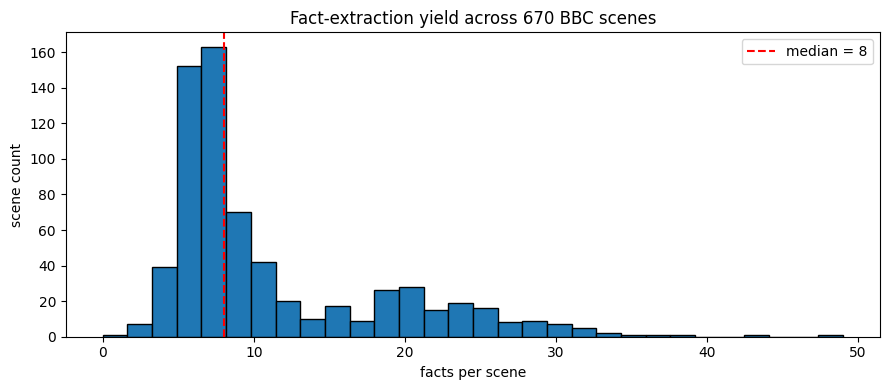

In [21]:
import matplotlib.pyplot as plt

facts_per_scene = df_facts["n_facts"]
print(facts_per_scene.describe().round(2))

plt.figure(figsize=(9, 4))
plt.hist(facts_per_scene, bins=30, edgecolor="black")
plt.axvline(facts_per_scene.median(), color="red", linestyle="--",
            label=f"median = {facts_per_scene.median():.0f}")
plt.xlabel("facts per scene")
plt.ylabel("scene count")
plt.title(f"Fact-extraction yield across {len(df_facts)} BBC scenes")
plt.legend()
plt.tight_layout()
plt.show()


category_broad
entity       2516
relation     1421
attribute    1384
event        1197
action        721
global        219
other          26
Name: count, dtype: int64


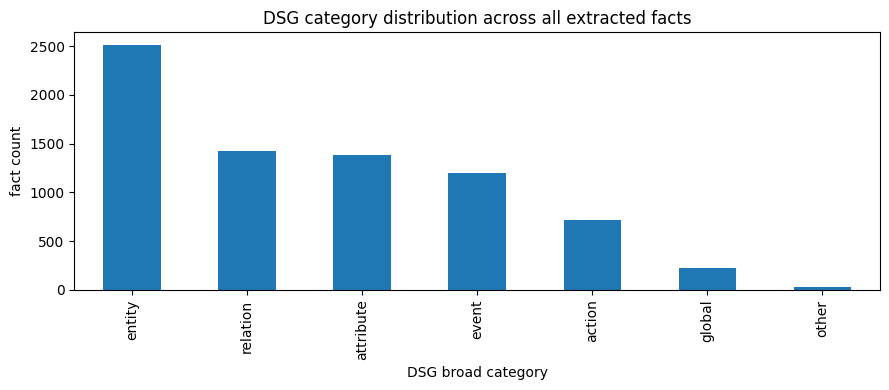

In [22]:
category_counts = (
    df_facts_long["category_broad"].fillna("unparseable").value_counts()
)
print(category_counts)

plt.figure(figsize=(9, 4))
category_counts.plot(kind="bar")
plt.xlabel("DSG broad category")
plt.ylabel("fact count")
plt.title("DSG category distribution across all extracted facts")
plt.tight_layout()
plt.show()


#### Analysis Conclusions

* **Length.** BBC scenes average **48.3 s** (median 40.5 s, range 0.8-208 s) against
  MSR-VTT's ~ 15 s mean and 10–32 s cap (Xu et al., CVPR 2016). Mean-to-mean this is a
  **~3.2× stretch**; the longest BBC scene is **6.5× longer** than anything in MSR-VTT.
  The FIFA pipeline was not validated on content this long, so the extractor is being
  asked to summarize a description of 30 s+ of multi-shot cinematic content into a
  single tuple set. This is the kind of content we want to test the FIFA methodology on.

### Generate Questions

  Rewrite each atomic tuple as a natural-language yes/no question of the form
  `id | question`, keyed by the same fact IDs assigned in the previous step.
  These questions are what the downstream VQA model answers directly from the
  video — its yes/no responses become the raw faithfulness signal per fact, one
  signal per tuple.

In [23]:
import time


def batch_generate_questions(df, llm, config, pace_seconds: float = 0.0):
    """Generate questions per scene with optional pacing between requests.

    Set pace_seconds > 0 when the LLM is rate-limited (e.g. gpt-4o Tier 1
    at 30k TPM). Pacing spreads request timing so the SDK's exponential
    backoff has to handle fewer 429 bursts.
    """
    all_questions_records = []
    total = len(df)

    print(
        f"Starting question generation for {total} scenes "
        f"(pace_seconds={pace_seconds})..."
    )

    for idx, row in df.iterrows():
        try:
            description = row['description']
            raw_tuples = row['raw_tuples']
            facts = json.loads(row['facts_json'])
            valid_ids = {f['id'] for f in facts}

            # Prepare prompt using the utility
            question_prompt = fifa.make_prompt(
                examples=fifa._QUESTION_EXAMPLES,
                test_input="\n".join([description, raw_tuples]),
                test_query="What happens in the scene?",
                preamble=fifa._QUESTION_PREAMBLE,
                task="question"
            )

            # Get completion from LLM
            raw_question_output = llm.completion(
                prompt=question_prompt,
                config=config
            )

            # Parse questions
            questions, _ = parse_questions(raw_question_output, valid_ids=valid_ids)

            all_questions_records.append({
                "video_id": row['video_id'],
                "scene_id": row['scene_id'],
                "raw_questions": raw_question_output,
                "questions_json": json.dumps(questions)
            })

            if (idx + 1) % 10 == 0:
                print(f"  Processed {idx + 1}/{total} scenes")

        except Exception as e:
            print(f"  Error processing index {idx}: {e}")

        if pace_seconds > 0:
            time.sleep(pace_seconds)

    return pd.DataFrame(all_questions_records)


In [24]:
# gpt-4o Tier 1 = 30k TPM. Each request is ~5-6k tokens, so pacing at ~6s
# keeps the average request rate under the limit and lets the SDK's built-in
# exponential backoff handle occasional bursts. Bump to 10-12s if 429s persist,
# drop to 0 if you're on a higher tier or using a non-rate-limited backend.
QUESTIONS_PACE_SECONDS = 6.0

if QUESTIONS_CACHE_PATH.exists():
    df_questions = pd.read_csv(QUESTIONS_CACHE_PATH)
    print(f"Scene questions already at: {QUESTIONS_CACHE_PATH}")
else:
    QUESTIONS_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    df_questions = batch_generate_questions(
        df_facts,
        extractor_llm,
        QUESTION_GENERATION_CONFIG,
        pace_seconds=QUESTIONS_PACE_SECONDS,
    )
    df_questions.to_csv(QUESTIONS_CACHE_PATH, index=False)
    print(f"Results successfully cached to: {QUESTIONS_CACHE_PATH}")


Scene questions already at: /content/bbc/runs/qwen35-gpt4o/scene_questions.csv


In [25]:
display(df_questions.head())

,video_id,scene_id,raw_questions,questions_json
0,bbc_01,scene_000.mp4,1 | Is there a black screen?\n2 | Is there Ear...,"{""1"": ""Is there a black screen?"", ""2"": ""Is the..."
1,bbc_01,scene_001.mp4,1 | Is there a camera?\n2 | Is there a mountai...,"{""1"": ""Is there a camera?"", ""2"": ""Is there a m..."
2,bbc_01,scene_002.mp4,1 | Is there a group of penguins?\n2 | Is ther...,"{""1"": ""Is there a group of penguins?"", ""2"": ""I..."
3,bbc_01,scene_003.mp4,1 | Are there penguins?\n2 | Is there ice?\n3 ...,"{""1"": ""Are there penguins?"", ""2"": ""Is there ic..."
4,bbc_01,scene_004.mp4,1 | Is there a sun?\n2 | Is there a mountain r...,"{""1"": ""Is there a sun?"", ""2"": ""Is there a moun..."


#### Question-generation analysis

The next four plots characterize the fact→question conversion step on the BBC
scene set. Each addresses a distinct pipeline-quality concern the proposal calls
out:

1. **Coverage per scene** — fraction of extracted facts that received a question.
   Directly comparable to the FIFA paper's Table 2 metric (99.04% fact-to-question
   conversion accuracy).
2. **Yes/no shape validity** — fraction of generated questions that open with a
   yes/no verb. The downstream scoring code (`_AFFIRM` / `_DENY` sets) assumes
   yes/no answers; malformed questions poison the fact-level score independently
   of VQA quality.
3. **Coverage by DSG category** — which fact types the generator handles reliably
   vs. drops. Cross-references FIFA's Table 6 per-category VQA accuracy for
   compounded-loss analysis.
4. **Question length by category** — mean and spread of word count per fact
   category. Long, compound questions on temporal or event facts compound the VQA
   difficulty already visible in FIFA Table 6.


In [26]:
import json
import pandas as pd

df_facts["parsed_facts"] = df_facts["facts_json"].apply(json.loads)
df_facts["n_facts"] = df_facts["parsed_facts"].apply(len)

df_questions["parsed_questions"] = df_questions["questions_json"].apply(
    lambda s: {int(k): v for k, v in json.loads(s).items()}
)
df_questions["n_questions"] = df_questions["parsed_questions"].apply(len)

qs_by_scene = df_questions.set_index(["video_id", "scene_id"])[["parsed_questions"]]

df_qcoverage = df_facts.set_index(["video_id", "scene_id"])[["n_facts"]].copy()

# Reindex qs_by_scene to match df_qcoverage's index, filling missing parsed_questions with empty dicts.
# This ensures n_questions will always be an integer and not NaN.
reindexed_qs_by_scene = qs_by_scene.reindex(df_qcoverage.index)
reindexed_qs_by_scene["parsed_questions"] = reindexed_qs_by_scene["parsed_questions"].fillna({})
# Explicitly check for dict type before applying len to prevent TypeError on floats
df_qcoverage["n_questions"] = reindexed_qs_by_scene["parsed_questions"].apply(lambda x: len(x) if isinstance(x, dict) else 0)

df_qcoverage["coverage"] = (
    df_qcoverage["n_questions"] / df_qcoverage["n_facts"].replace(0, pd.NA)
)
df_qcoverage = df_qcoverage.reset_index()

records = []
for _, row in df_facts.iterrows():
    key = (row["video_id"], row["scene_id"])
    q_dict = {}
    try:
        # Correctly access the parsed_questions dictionary for the current scene
        q_dict_potential = qs_by_scene.loc[key, "parsed_questions"]
        if isinstance(q_dict_potential, dict):
            q_dict = q_dict_potential
    except KeyError:
        # If the scene has no questions in df_questions, q_dict remains empty
        pass

    for f in row["parsed_facts"]:
        if not isinstance(f, dict):
            continue
        fid = f.get("id")
        records.append({
            "video_id": row["video_id"],
            "scene_id": row["scene_id"],
            "fact_id": fid,
            "category_broad": f.get("category_broad"),
            "question": q_dict.get(fid),
        })
df_qfacts_long = pd.DataFrame(records)
df_qfacts_long["has_question"] = df_qfacts_long["question"].notna()

n_facts = len(df_qfacts_long)
n_with_q = int(df_qfacts_long["has_question"].sum())
print(f"{len(df_qcoverage)} scenes, {n_facts} facts, "
      f"{n_with_q} received a question ({n_with_q / n_facts:.2%} overall)")

670 scenes, 7484 facts, 7484 received a question (100.00% overall)


count     669.0
unique      1.0
top         1.0
freq      669.0
Name: coverage, dtype: float64


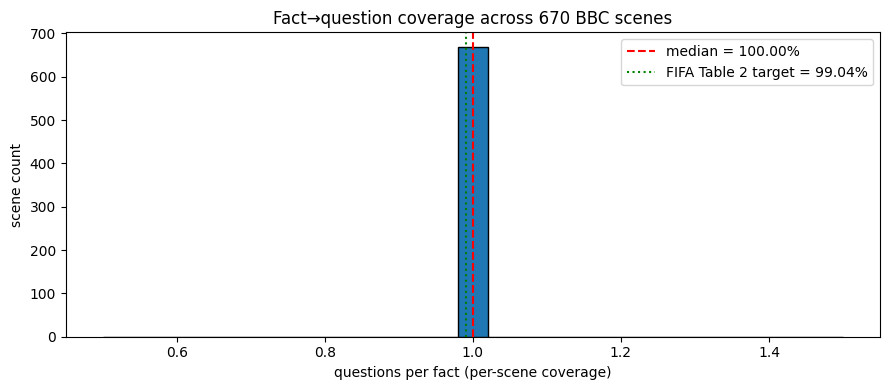

In [27]:
import matplotlib.pyplot as plt

coverage = df_qcoverage["coverage"].dropna()
print(coverage.describe().round(3))

plt.figure(figsize=(9, 4))
plt.hist(coverage, bins=25, edgecolor="black")
plt.axvline(coverage.median(), color="red", linestyle="--",
            label=f"median = {coverage.median():.2%}")
plt.axvline(0.9904, color="green", linestyle=":",
            label="FIFA Table 2 target = 99.04%")
plt.xlabel("questions per fact (per-scene coverage)")
plt.ylabel("scene count")
plt.title(f"Fact→question coverage across {len(df_qcoverage)} BBC scenes")
plt.legend()
plt.tight_layout()
plt.show()


yes/no-shaped questions: 7484 / 7484 (100.00%)


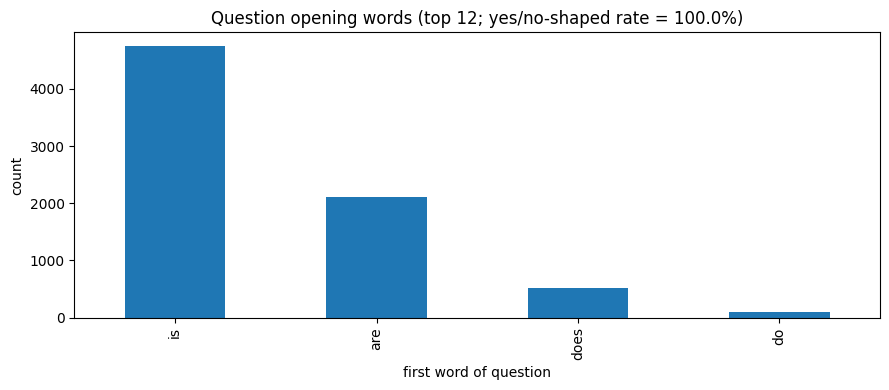

In [28]:
import re

YESNO_OPENERS = {
    "is", "are", "does", "do", "did", "has", "have", "was", "were",
    "can", "could", "should", "would", "will", "may", "might",
}


def opener(q):
    if not isinstance(q, str):
        return None
    m = re.match(r"^\s*([A-Za-z]+)", q.lower())
    return m.group(1) if m else None


df_qfacts_long["opener"] = df_qfacts_long["question"].apply(opener)
opener_counts = df_qfacts_long["opener"].fillna("(no question)").value_counts()

yesno_ok = df_qfacts_long["opener"].isin(YESNO_OPENERS)
n_with_q = int(df_qfacts_long["has_question"].sum())
yesno_rate = int(yesno_ok.sum()) / n_with_q if n_with_q else 0.0

print(f"yes/no-shaped questions: {int(yesno_ok.sum())} / {n_with_q} ({yesno_rate:.2%})")

top_openers = opener_counts.head(12)
plt.figure(figsize=(9, 4))
top_openers.plot(kind="bar")
plt.xlabel("first word of question")
plt.ylabel("count")
plt.title(f"Question opening words (top 12; yes/no-shaped rate = {yesno_rate:.1%})")
plt.tight_layout()
plt.show()


                coverage  n_with_question  n_facts
category_broad                                    
entity               1.0             2516     2516
relation             1.0             1421     1421
attribute            1.0             1384     1384
event                1.0             1197     1197
action               1.0              721      721
global               1.0              219      219
other                1.0               26       26


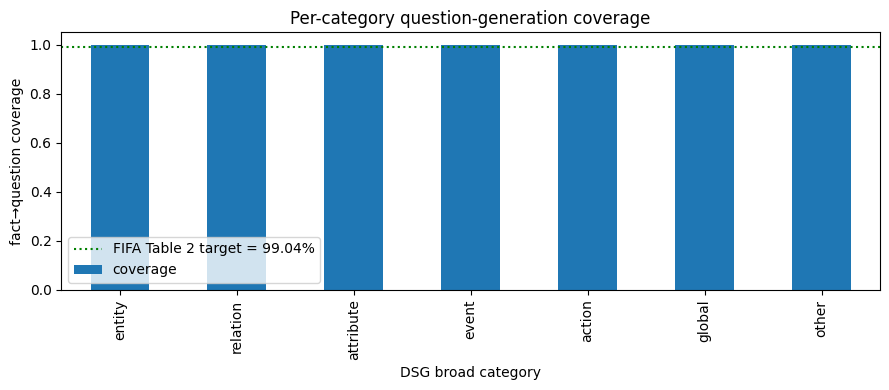

In [29]:
category_coverage = (
    df_qfacts_long
    .groupby("category_broad")["has_question"]
    .agg(coverage="mean", n_with_question="sum", n_facts="count")
    .sort_values("n_facts", ascending=False)
)
print(category_coverage.round(3))

plt.figure(figsize=(9, 4))
category_coverage["coverage"].plot(kind="bar")
plt.axhline(0.9904, color="green", linestyle=":",
            label="FIFA Table 2 target = 99.04%")
plt.xlabel("DSG broad category")
plt.ylabel("fact→question coverage")
plt.ylim(0, 1.05)
plt.title("Per-category question-generation coverage")
plt.legend()
plt.tight_layout()
plt.show()


  plt.boxplot(groups, labels=wc_stats.index.tolist(), showfliers=False)



                mean  median   std  count
category_broad                           
entity          4.01     4.0  0.95   2516
relation        7.03     7.0  1.51   1421
attribute       4.84     4.0  1.31   1384
event           9.87     9.0  3.25   1197
action          6.35     7.0  1.68    721
global          4.80     5.0  0.47    219
other           5.31     5.5  0.97     26


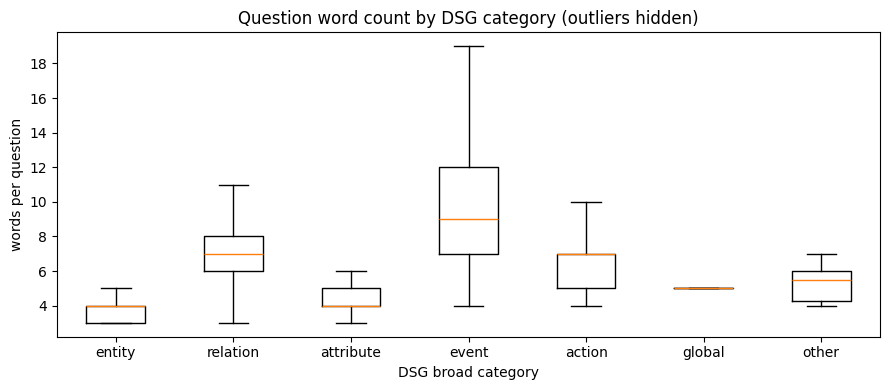

In [30]:
df_qfacts_long["question_wc"] = df_qfacts_long["question"].apply(
    lambda q: len(q.split()) if isinstance(q, str) else None
)

wc_stats = (
    df_qfacts_long
    .dropna(subset=["question_wc", "category_broad"])
    .groupby("category_broad")["question_wc"]
    .agg(mean="mean", median="median", std="std", count="count")
    .sort_values("count", ascending=False)
)
print(wc_stats.round(2))

groups = [
    df_qfacts_long.loc[
        (df_qfacts_long["category_broad"] == cat)
        & df_qfacts_long["question_wc"].notna(),
        "question_wc",
    ].values
    for cat in wc_stats.index
]

plt.figure(figsize=(9, 4))
plt.boxplot(groups, labels=wc_stats.index.tolist(), showfliers=False)
plt.title("Question word count by DSG category (outliers hidden)")
plt.xlabel("DSG broad category")
plt.ylabel("words per question")
plt.tight_layout()
plt.show()


#### Analysis Conclusions

**Coverage.** 7,484 / 7,484 = **100.00%** fact→question conversion across
670 BBC scenes

**Yes/no shape validity: 100%.** Every one of 7,484 questions opens with a
yes/no verb. The downstream scoring code (`_AFFIRM` / `_DENY` sets in the Verify
Facts section) assumes yes/no answers; open-ended drift would silently poison
the fact-level score independently of VQA quality.

**Question length by category** — These findings matter most for assessing the risks to our research question. Events produce ~2.5x longer questions than entities (9.9 vs 4.0 words) with 3.4x the standard deviation (3.25 vs 0.95). The two proposal-relevant implications are:

- **Compounded difficulty on event/temporal categories.** Cross-referencing with
  FIFA Table 6, entity/attribute VQA accuracy runs 73-90% while events drop to
  52-63%. The questions asked of the VQA in the already-weakest category are
  also the longest and most variable.

- **Per-category injection sensitivity for Goal 2.** Injecting a hallucination
  into an event fact ("Does the man walk from the doorway to the table while
  carrying a tray?") gives the VQA multiple partial correctnesses to hang a
  "yes" on.

Pipeline-quality metrics (100% coverage, 100% yes/no validity)
show the fact and question conversion step is robust on cinematic content which meets Goal 1. Category-conditioned question length quantifies where downstream
verification is likely hardest, event/temporal categories, providing concrete
evidence for Risk 1 and a principled reason to report Goal 2 injection
sensitivity per category rather than aggregated.


### Dependency Graph Generation



In [31]:
def batch_generate_dependencies(df, llm, config, pace_seconds: float = 0.0):
    """Generate dependency lists per scene with optional pacing between requests.

    Set pace_seconds > 0 when the LLM is rate-limited (e.g. gpt-4o Tier 1
    at 30k TPM). Pacing spreads request timing so the SDK's exponential
    backoff has to handle fewer 429 bursts.
    """
    all_deps_records = []
    total = len(df)

    print(
        f"Starting dependency generation for {total} scenes "
        f"(pace_seconds={pace_seconds})..."
    )

    for idx, row in df.iterrows():
        try:
            description = row['description']
            raw_tuples = row['raw_tuples']
            facts = json.loads(row['facts_json'])
            valid_ids = {f['id'] for f in facts}

            # Prepare prompt using the utility
            dependency_prompt = fifa.make_prompt(
                examples=fifa._DEPENDENCY_EXAMPLES,
                test_input="\n".join([description, raw_tuples]),
                test_query="What happens in the scene?",
                preamble=fifa._DEPENDENCY_PREAMBLE,
                task="dependency"
            )

            # Get completion from LLM
            raw_dependency_output = llm.completion(
                prompt=dependency_prompt,
                config=config
            )

            # Parse dependencies
            dependencies, _, _ = parse_dependencies(
                raw_dependency_output,
                valid_ids=valid_ids
            )

            all_deps_records.append({
                "video_id": row['video_id'],
                "scene_id": row['scene_id'],
                "raw_dependencies": raw_dependency_output,
                "dependencies_json": json.dumps(dependencies)
            })

            if (idx + 1) % 10 == 0:
                print(f"  Processed {idx + 1}/{total} scenes")

        except Exception as e:
            print(f"  Error processing index {idx}: {e}")

        if pace_seconds > 0:
            time.sleep(pace_seconds)

    return pd.DataFrame(all_deps_records)


In [32]:
# gpt-4o Tier 1 = 30k TPM. Each request is ~5-6k tokens, so pacing at ~6s
# keeps the average request rate under the limit and lets the SDK's built-in
# exponential backoff handle occasional bursts. Bump to 10-12s if 429s persist,
# drop to 0 if you're on a higher tier or using a non-rate-limited backend.
DEPENDENCIES_PACE_SECONDS = 6.0

if GRAPH_CACHE_PATH.exists():
    df_dependencies = pd.read_csv(GRAPH_CACHE_PATH)
    print(f"Scene dependencies already at: {GRAPH_CACHE_PATH}")
else:
    GRAPH_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    df_dependencies = batch_generate_dependencies(
        df_facts,
        extractor_llm,
        GRAPH_GENERATION_CONFIG,
        pace_seconds=DEPENDENCIES_PACE_SECONDS,
    )
    df_dependencies.to_csv(GRAPH_CACHE_PATH, index=False)
    print(f"Results successfully cached to: {GRAPH_CACHE_PATH}")


Starting dependency generation for 670 scenes (pace_seconds=6.0)...
  Processed 10/670 scenes
  Processed 20/670 scenes
  Processed 30/670 scenes
  Processed 40/670 scenes
  Processed 50/670 scenes
  Processed 60/670 scenes
  Error processing index 65: sequence item 1: expected str instance, float found
  Processed 70/670 scenes
  Processed 80/670 scenes
  Processed 90/670 scenes
  Processed 100/670 scenes
  Processed 110/670 scenes
  Processed 120/670 scenes
  Processed 130/670 scenes
  Processed 140/670 scenes
  Processed 150/670 scenes
  Processed 160/670 scenes
  Processed 170/670 scenes
  Processed 180/670 scenes
  Processed 190/670 scenes
  Processed 200/670 scenes
  Processed 210/670 scenes
  Processed 220/670 scenes
  Processed 230/670 scenes
  Processed 240/670 scenes
  Processed 250/670 scenes
  Processed 260/670 scenes
  Processed 270/670 scenes
  Processed 280/670 scenes
  Processed 290/670 scenes
  Processed 300/670 scenes
  Processed 310/670 scenes
  Processed 320/670 sce

In [34]:
display(df_dependencies.head())

,video_id,scene_id,raw_dependencies,dependencies_json
0,bbc_01,scene_000.mp4,1 | 0\n2 | 0\n3 | 0\n4 | 0\n5 | 0\n6 | 0\n7 | ...,"{""1"": [], ""2"": [], ""3"": [], ""4"": [], ""5"": [], ..."
1,bbc_01,scene_001.mp4,"1 | 0\n2 | 0\n3 | 0\n4 | 1\n5 | 3\n6 | 4,5","{""1"": [], ""2"": [], ""3"": [], ""4"": [1], ""5"": [3]..."
2,bbc_01,scene_002.mp4,"1 | 0\n2 | 0\n3 | 0\n4 | 1\n5 | 1,2\n6 | 2,3\n...","{""1"": [], ""2"": [], ""3"": [], ""4"": [1], ""5"": [1,..."
3,bbc_01,scene_003.mp4,"1 | 0\n2 | 0\n3 | 0\n4 | 1\n5 | 1\n6 | 1,2\n7 ...","{""1"": [], ""2"": [], ""3"": [], ""4"": [1], ""5"": [1]..."
4,bbc_01,scene_004.mp4,"1 | 0\n2 | 0\n3 | 0\n4 | 1\n5 | 1\n6 | 1,2\n7 ...","{""1"": [], ""2"": [], ""3"": [], ""4"": [1], ""5"": [1]..."


#### Dependency-graph analysis

The next four plots characterize the STSDG structure the extractor produced on
the BBC scene set. Each addresses a distinct pipeline-quality or applicability
concern the proposal calls out:

1. **Root-fact rate per scene** — fraction of facts with no declared parents.
   High root rate means the graph is flat and FIFA's transitive score
   propagation is effectively inactive; direct evidence for the proposal's
   Risk 1.
2. **DAG validity rate** — fraction of scenes that produced a well-formed
   acyclic graph. Directly comparable to the FIFA paper's Table 2 metric
   (99.03–99.06% dependency validity ratio).
3. **Max chain depth per scene** — longest root-to-leaf path. Deep chains mean
   injecting a hallucination at a root propagates a zero-score to many
   descendants (large Goal 2 effect); shallow chains mean small effects.
4. **Root rate by DSG category** — sanity check on taxonomy adherence. Entities
   and attributes should dominate the root layer (foundational claims);
   actions and events should typically have parents (grounded in entities).


In [35]:
import json
import pandas as pd
import networkx as nx

df_dependencies["parsed_deps"] = df_dependencies["dependencies_json"].apply(
    lambda s: {int(k): [int(p) for p in v] for k, v in json.loads(s).items()}
)

deps_by_scene = (
    df_dependencies.set_index(["video_id", "scene_id"])["parsed_deps"].to_dict()
)


def _scene_graph_stats(fact_ids, deps):
    G = nx.DiGraph()
    G.add_nodes_from(fact_ids)
    for child, parents in deps.items():
        if child not in fact_ids:
            continue
        for p in parents:
            if p in fact_ids and p != child:
                G.add_edge(p, child)

    n_edges = G.number_of_edges()
    is_dag = nx.is_directed_acyclic_graph(G) if len(G) else True
    roots = [n for n in G.nodes if G.in_degree(n) == 0]
    n_roots = len(roots)
    n_facts = len(fact_ids)

    max_depth = None
    if is_dag and n_facts > 0:
        depths = {}
        for n in nx.topological_sort(G):
            preds = list(G.predecessors(n))
            depths[n] = 1 + max(depths[p] for p in preds) if preds else 0
        max_depth = max(depths.values()) if depths else 0

    return {
        "n_facts": n_facts,
        "n_edges": n_edges,
        "n_roots": n_roots,
        "root_rate": n_roots / n_facts if n_facts else None,
        "max_depth": max_depth,
        "is_valid_dag": is_dag,
    }


stat_rows = []
long_rows = []
for _, row in df_facts.iterrows():
    key = (row["video_id"], row["scene_id"])
    facts = [f for f in row["parsed_facts"] if isinstance(f, dict)]
    fact_ids = {f["id"] for f in facts}
    deps = deps_by_scene.get(key, {}) or {}

    stat_rows.append({
        "video_id": row["video_id"],
        "scene_id": row["scene_id"],
        **_scene_graph_stats(fact_ids, deps),
    })

    for f in facts:
        fid = f.get("id")
        parents = deps.get(fid, [])
        long_rows.append({
            "video_id": row["video_id"],
            "scene_id": row["scene_id"],
            "fact_id": fid,
            "category_broad": f.get("category_broad"),
            "n_parents": len(parents),
            "is_root": len(parents) == 0,
        })

df_dstats = pd.DataFrame(stat_rows)
df_dfacts_long = pd.DataFrame(long_rows)

print(f"{len(df_dstats)} scenes, {len(df_dfacts_long)} facts, "
      f"{int(df_dstats['n_edges'].sum())} total dependency edges")


670 scenes, 7484 facts, 7478 total dependency edges


count    669.000
mean       0.410
std        0.130
min        0.069
25%        0.333
50%        0.381
75%        0.500
max        0.909
Name: root_rate, dtype: float64
scenes with 0 edges (all facts are roots): 1


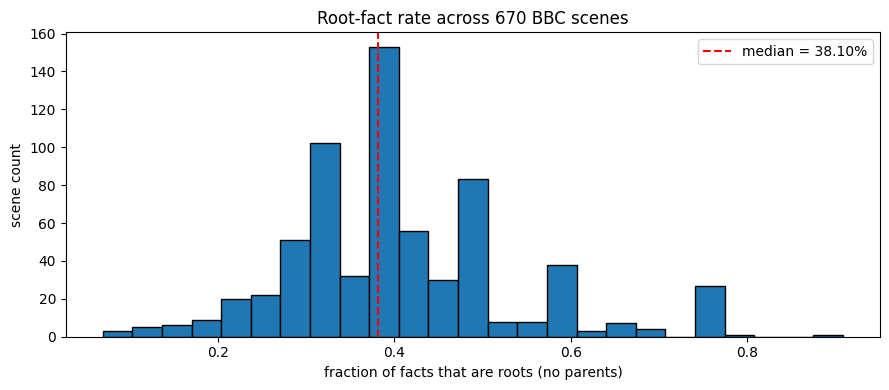

In [36]:
import matplotlib.pyplot as plt

root_rate = df_dstats["root_rate"].dropna()
print(root_rate.describe().round(3))
print(f"scenes with 0 edges (all facts are roots): "
      f"{int((df_dstats['n_edges'] == 0).sum())}")

plt.figure(figsize=(9, 4))
plt.hist(root_rate, bins=25, edgecolor="black")
plt.axvline(root_rate.median(), color="red", linestyle="--",
            label=f"median = {root_rate.median():.2%}")
plt.xlabel("fraction of facts that are roots (no parents)")
plt.ylabel("scene count")
plt.title(f"Root-fact rate across {len(df_dstats)} BBC scenes")
plt.legend()
plt.tight_layout()
plt.show()


In [37]:
n_valid = int(df_dstats["is_valid_dag"].sum())
n_total = len(df_dstats)
validity_rate = n_valid / n_total if n_total else 0.0

print(f"DAG-valid scenes:      {n_valid} / {n_total} ({validity_rate:.2%})")
print(f"FIFA Table 2 target:   99.03% – 99.06% dependency validity ratio")

invalid = df_dstats[~df_dstats["is_valid_dag"]]
if not invalid.empty:
    print(f"\nCyclic scenes ({len(invalid)}):")
    print(
        invalid[["video_id", "scene_id", "n_facts", "n_edges"]]
        .head(20)
        .to_string(index=False)
    )


DAG-valid scenes:      670 / 670 (100.00%)
FIFA Table 2 target:   99.03% – 99.06% dependency validity ratio


count    669.00
mean       1.99
std        0.48
min        1.00
25%        2.00
50%        2.00
75%        2.00
max        4.00
Name: max_depth, dtype: float64


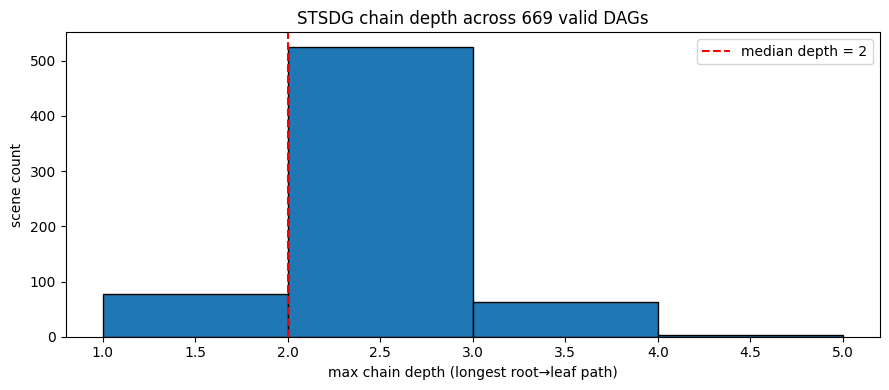

In [38]:
max_depth = df_dstats["max_depth"].dropna()
print(max_depth.describe().round(2))

bins = range(int(max_depth.min()), int(max_depth.max()) + 2)
plt.figure(figsize=(9, 4))
plt.hist(max_depth, bins=bins, edgecolor="black")
plt.axvline(max_depth.median(), color="red", linestyle="--",
            label=f"median depth = {max_depth.median():.0f}")
plt.xlabel("max chain depth (longest root→leaf path)")
plt.ylabel("scene count")
plt.title(f"STSDG chain depth across {len(max_depth)} valid DAGs")
plt.legend()
plt.tight_layout()
plt.show()


                root_rate  n_facts
category_broad                    
entity              0.924     2516
relation            0.016     1421
attribute           0.142     1384
event               0.002     1197
action              0.104      721
global              1.000      219
other               0.077       26


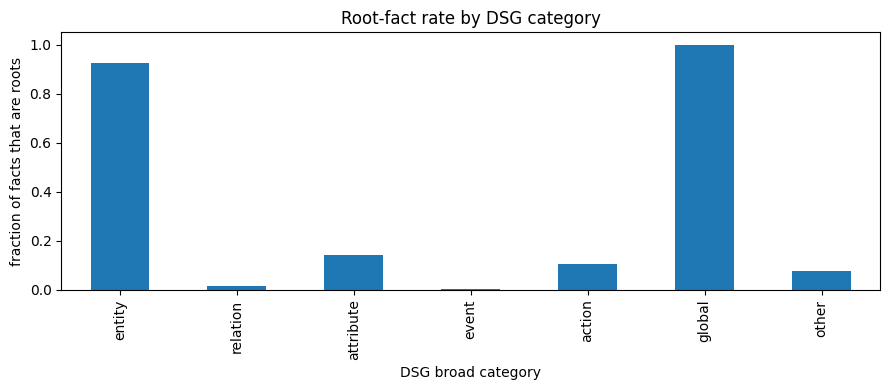

In [39]:
cat_root = (
    df_dfacts_long
    .groupby("category_broad")["is_root"]
    .agg(root_rate="mean", n_facts="count")
    .sort_values("n_facts", ascending=False)
)
print(cat_root.round(3))

plt.figure(figsize=(9, 4))
cat_root["root_rate"].plot(kind="bar")
plt.xlabel("DSG broad category")
plt.ylabel("fraction of facts that are roots")
plt.ylim(0, 1.05)
plt.title("Root-fact rate by DSG category")
plt.tight_layout()
plt.show()


### Visualize Graph

In [40]:
from graph import build_fifa_graph, draw_fifa_graph


In [41]:
first_scene_facts_row = df_facts.iloc[0]
first_scene_questions_row = df_questions[
    (df_questions['video_id'] == first_scene_facts_row['video_id']) &
    (df_questions['scene_id'] == first_scene_facts_row['scene_id'])
].iloc[0]
first_scene_dependencies_row = df_dependencies[
    (df_dependencies['video_id'] == first_scene_facts_row['video_id']) &
    (df_dependencies['scene_id'] == first_scene_facts_row['scene_id'])
].iloc[0]


facts_for_single_scene = json.loads(first_scene_facts_row['facts_json'])


questions_for_single_scene_str_keys = json.loads(first_scene_questions_row['questions_json'])
questions_for_single_scene = {int(k): v for k, v in questions_for_single_scene_str_keys.items()}

dependencies_for_single_scene_str_keys = json.loads(first_scene_dependencies_row['dependencies_json'])
dependencies_for_single_scene = {int(k): v for k, v in dependencies_for_single_scene_str_keys.items()}


G = build_fifa_graph(
    facts_for_single_scene,
    questions_for_single_scene,
    dependencies_for_single_scene,
)

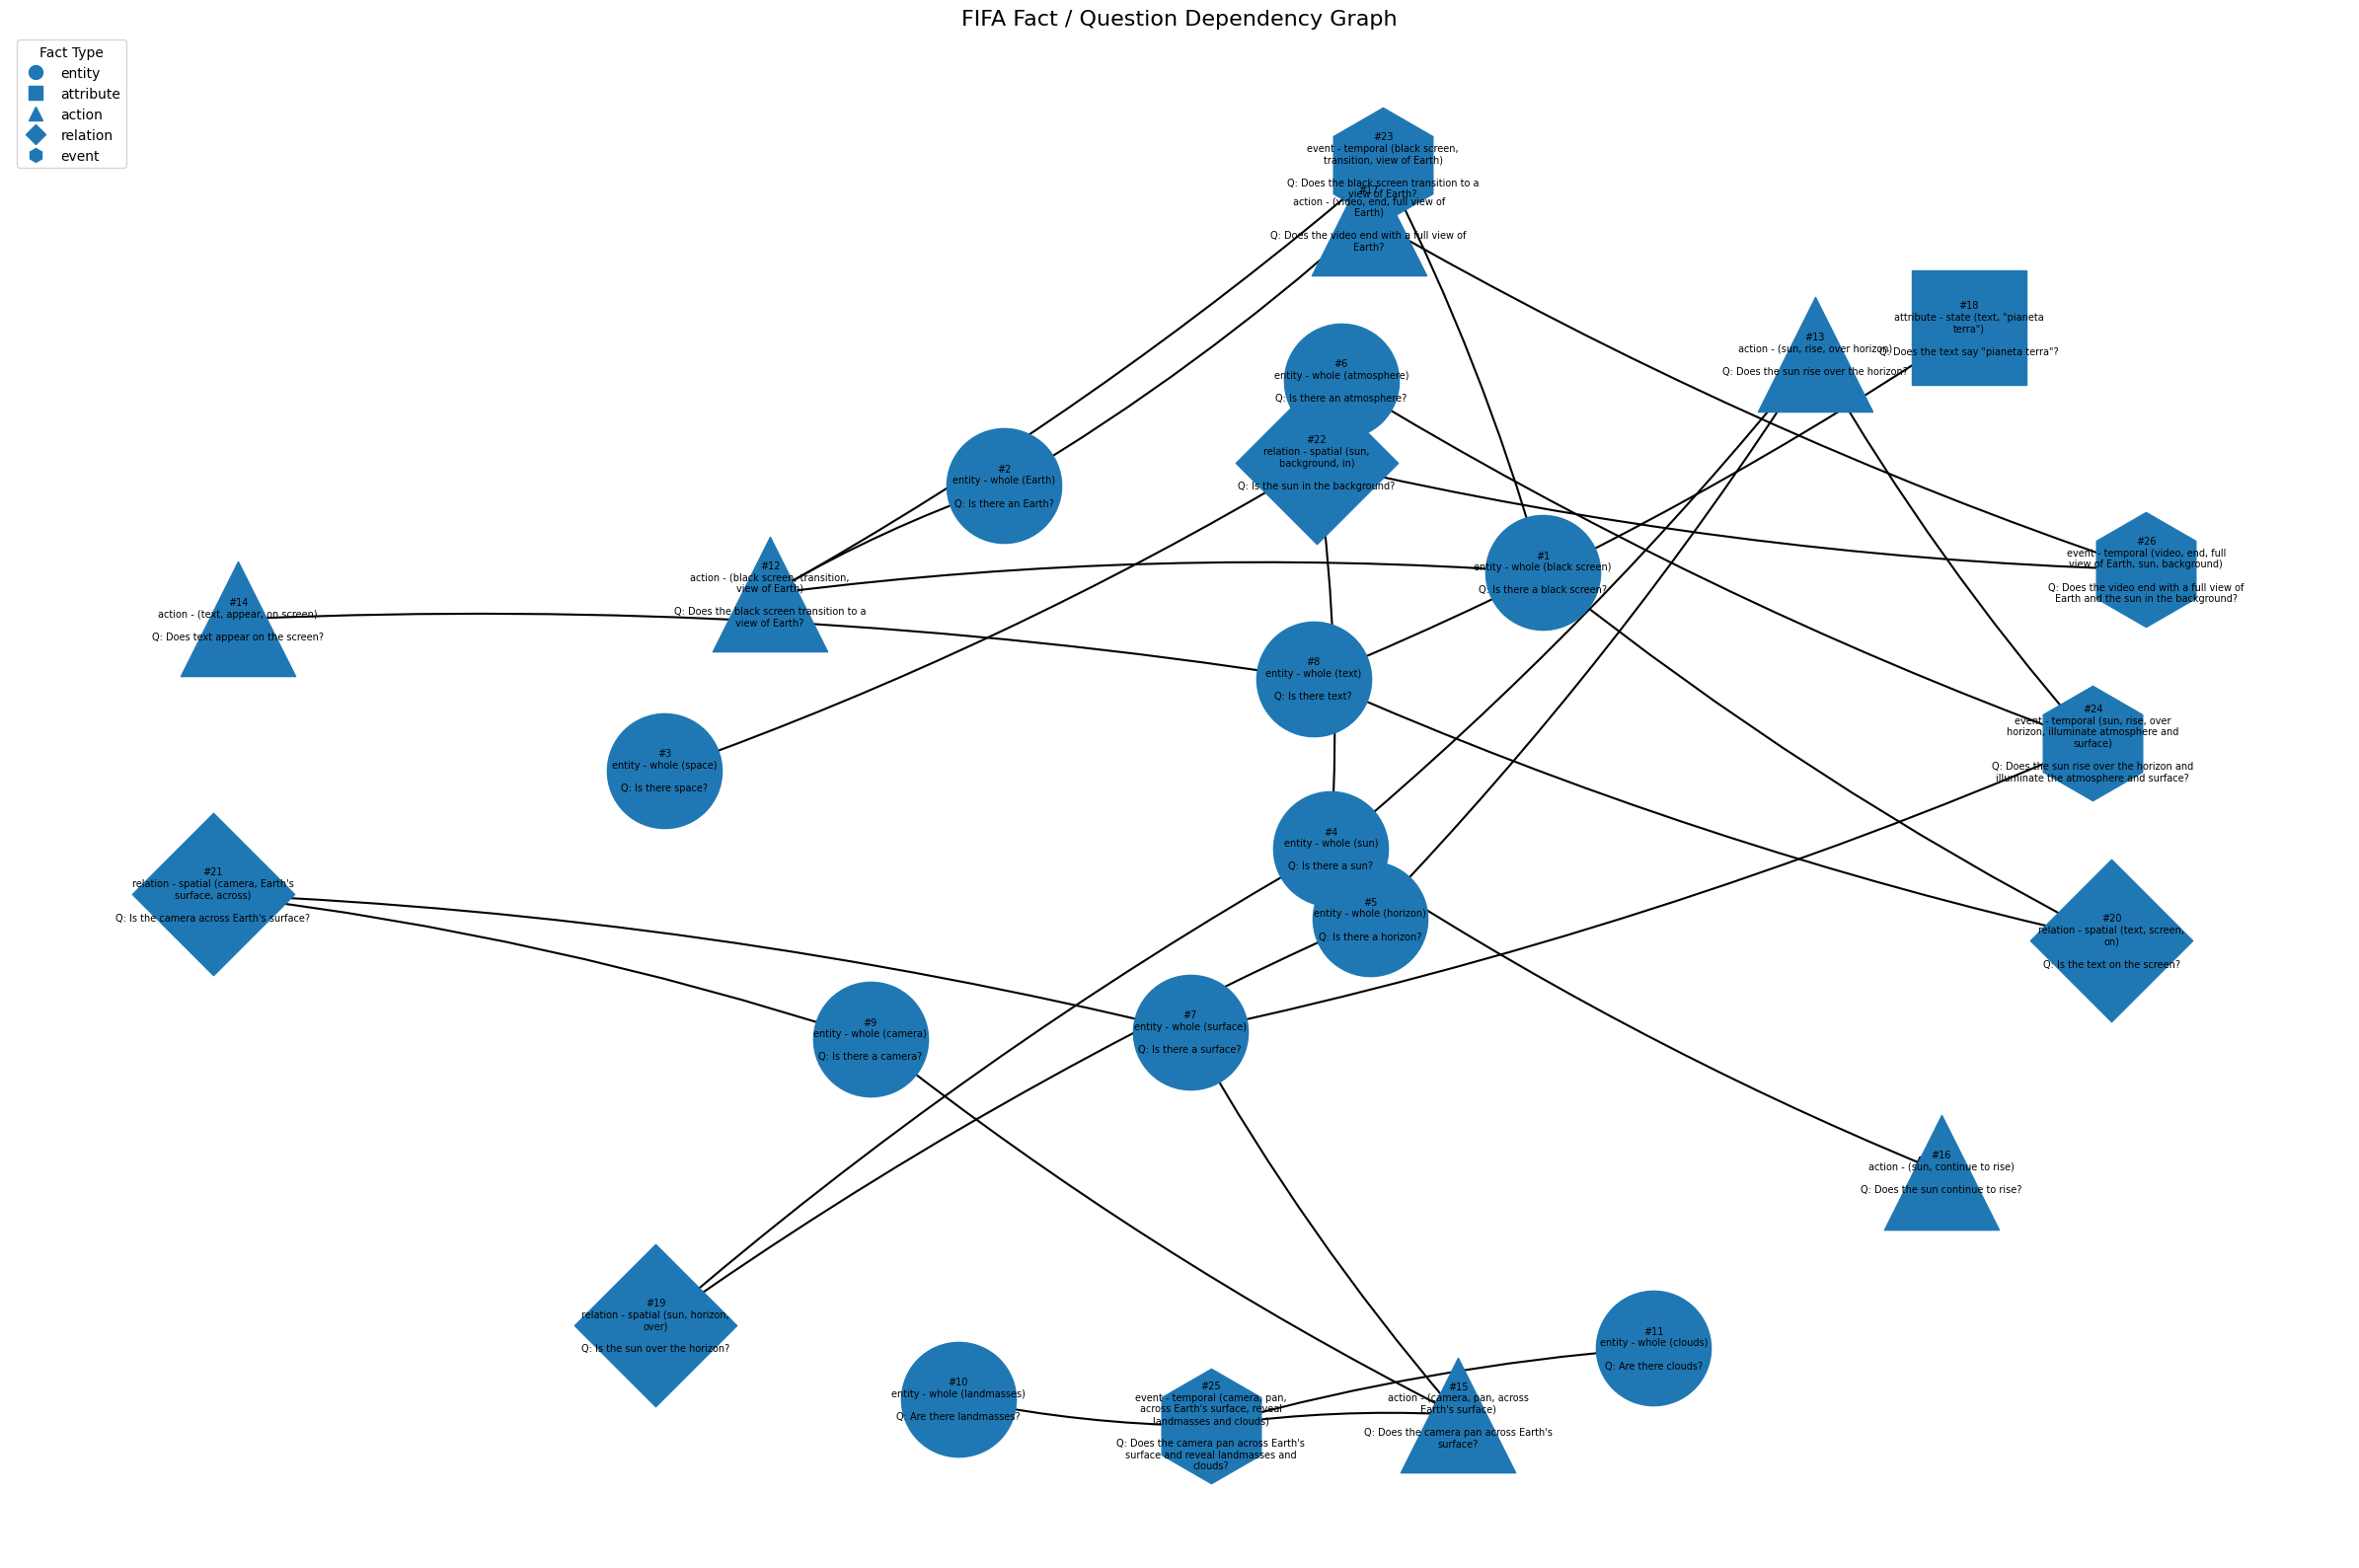

In [ ]:
draw_fifa_graph(G)

## Dependency Graph (STSDG)

In [ ]:
stsdg = [
    {
        **f,
        "question": questions.get(f["id"]),
        "parents": [p for p in dependencies.get(f["id"], []) if p != 0],
    }
    for f in facts
]

deps_clean = {
    k: [p for p in v if p != 0]
    for k, v in dependencies.items()
}

id2text = {f["id"]: f["text"] for f in facts}
for rec in stsdg:
    parents = ", ".join(id2text.get(p, f"?{p}") for p in rec["parents"]) or "-"
    print(f"{rec['id']:>3}  {rec['text']}")
    print(f"     Q: {rec['question']}")
    print(f"     parents: {parents}")

complete = [
    r for r in stsdg
    if r["question"] is not None and r["id"] in dependencies
]
print(f"\n{len(complete)}/{len(stsdg)} facts have a tuple, question and dependency entry")


  1  entity - whole (water bottles)
     Q: Is there a water bottle?
     parents: -
  2  other - count (water bottles, ==3)
     Q: Are there three water bottles?
     parents: entity - whole (water bottles)
  3  entity - whole (caps)
     Q: Are there caps?
     parents: -
  4  attribute - color (caps, blue)
     Q: Are the caps blue?
     parents: entity - whole (caps)
  5  attribute - state (water bottles, partially filled with water)
     Q: Are the water bottles partially filled with water?
     parents: entity - whole (water bottles)
  6  entity - whole (surface)
     Q: Is there a surface?
     parents: -
  7  attribute - color (surface, white)
     Q: Is the surface white?
     parents: entity - whole (surface)
  8  entity - whole (wall)
     Q: Is there a wall?
     parents: -
  9  attribute - color (wall, plain, light-colored)
     Q: Is the wall plain and light-colored?
     parents: entity - whole (wall)
 10  entity - whole (hand)
     Q: Is there a hand?
     parents: -
 

In [ ]:
def gold_dependencies(item_id):
    sub = fifa._TIFA160_DF[fifa._TIFA160_DF.item_id == item_id]
    gold = {}
    for n, raw in enumerate(sub.dependency.tolist()):
        parents = [
            int(t.strip()) for t in str(raw).split(",")
            if t.strip().isdigit() and int(t.strip()) != 0
        ]
        gold[n + 1] = parents
    return gold


def gold_for(item_id):
    sub = fifa._TIFA160_DF[fifa._TIFA160_DF.item_id == item_id]
    text = sub.text.tolist()[0]
    query = sub.input_query.tolist()[0]
    gold_tuples = sub.tuple.tolist()
    return text, query, gold_tuples, None


def build_examples(task, exclude_ids=frozenset()):
    ids = [i for i in fifa.TIFA160_ICL_TRAIN_IDS if i not in exclude_ids]
    return fifa.get_tifa_examples(fifa._TIFA160_DF, ids, task=task)


# Feed the GOLD tuples rather than the predicted ones, so this measures dependency
# generation in isolation instead of compounding tuple-extraction error.
for item_id in ("video_001", "video_002", "video_003"):
    text, query, gold_tuples, _ = gold_for(item_id)
    gold_block = "\n".join(f"{i + 1} | {t}" for i, t in enumerate(gold_tuples))
    p = fifa.make_prompt(
        examples=build_examples("dependency", exclude_ids={item_id}),
        test_input="\n".join([text, gold_block]),
        test_query=query,
        preamble=fifa._DEPENDENCY_PREAMBLE,
        task="dependency",
    )
    pred, dropped, _ = parse_dependencies(
        fifa.parse_with_input_name(
            extractor_llm.completion(p, config=GRAPH_GENERATION_CONFIG)
        ).strip(),
        valid_ids=set(range(1, len(gold_tuples) + 1)),
    )
    gold = gold_dependencies(item_id)

    exact = sum(1 for k in gold if set(pred.get(k, [])) == set(gold[k]))
    inter = sum(len(set(pred.get(k, [])) & set(gold[k])) for k in gold)
    union = sum(len(set(pred.get(k, [])) | set(gold[k])) for k in gold)
    print(f"\n{item_id}: {exact}/{len(gold)} exact parent-set match, "
          f"edge Jaccard {inter / union if union else 1.0:.2f}, dropped={len(dropped)}")
    for k in sorted(gold):
        mark = " " if set(pred.get(k, [])) == set(gold[k]) else "x"
        print(f"  {mark} {k:>3}  gold={gold[k] or '-'}  pred={pred.get(k, []) or '-'}")


video_001: 8/10 exact parent-set match, edge Jaccard 0.69, dropped=0
      1  gold=-  pred=-
      2  gold=-  pred=-
      3  gold=-  pred=-
      4  gold=-  pred=-
      5  gold=[1, 2]  pred=[1, 2]
      6  gold=[1, 3]  pred=[1, 3]
      7  gold=[1, 4]  pred=[4, 1]
  x   8  gold=[5, 7]  pred=[6, 5]
      9  gold=[6, 7]  pred=[7, 6]
  x  10  gold=[8, 9]  pred=[5, 6, 7, 8, 9]

video_002: 2/10 exact parent-set match, edge Jaccard 0.00, dropped=86
      1  gold=-  pred=-
      2  gold=-  pred=-
  x   3  gold=[1, 2]  pred=-
  x   4  gold=[1]  pred=-
  x   5  gold=[1]  pred=-
  x   6  gold=[1, 4]  pred=-
  x   7  gold=[1, 5]  pred=-
  x   8  gold=[3, 6]  pred=-
  x   9  gold=[3, 7]  pred=-
  x  10  gold=[6, 7]  pred=-

video_003: 5/9 exact parent-set match, edge Jaccard 0.44, dropped=0
      1  gold=-  pred=-
      2  gold=-  pred=-
      3  gold=-  pred=-
      4  gold=[1, 2]  pred=[1, 2]
      5  gold=[3]  pred=[3]
  x   6  gold=[1, 5]  pred=[1, 3]
  x   7  gold=[4, 7]  pred=[4, 6]
  x  

## Controlled Hallucination Injection

In [ ]:
DESCRIPTION = scene.summary
QUERY = "What happens in the scene?"

INJECTION_CONFIG = {
    "do_sample": True,
    "temperature": 0.2,
    "top_p": 0.9,
    "max_new_tokens": 512,
}


In [ ]:
import json

HALLUCINATION_TYPES = {
    "entity": "Replace one entity (a person, animal, or object) with a different one.",
    "attribute": "Change one attribute (colour, size, material, or state) of an entity.",
    "location": "Change the location or setting in which the scene takes place.",
    "action": "Change one action or verb to a different, incompatible action.",
    "relation": "Change a spatial relationship between two entities, or remove one participant.",
    "temporal": "Reverse the order of two events that occur in sequence.",
}

INJECT_PROMPT = """You are constructing a controlled evaluation set for a video \
description faithfulness metric.

Given a description, introduce EXACTLY ONE factual error of the requested type. The \
edit must be minimal: change as few words as possible and leave the rest of the \
description untouched.

Error type: {type_name}
Instruction: {type_instruction}

Description:
{description}

Respond with only a JSON object and no other text:
{{"hallucination_type": "{type_name}",
  "original_span": "<the exact substring of the description you are replacing, copied verbatim>",
  "replacement_span": "<the text that replaces it>",
  "rationale": "<one sentence stating what is now false>"}}

The value of "original_span" must appear verbatim in the description exactly once."""


def inject(description: str, htype: str, attempts: int = 4):
    """Return one minimally-perturbed variant, or None if every attempt failed.

    The model only proposes a span pair; the edit is applied here with str.replace so
    exactly one localised change is made. A model that rewrites the whole description
    would make any score drop unattributable to the injected error.
    """
    for _ in range(attempts):
        raw = extractor_llm.completion(
            INJECT_PROMPT.format(
                type_name=htype,
                type_instruction=HALLUCINATION_TYPES[htype],
                description=description,
            ),
            config=INJECTION_CONFIG,
        )
        try:
            payload = json.loads(raw[raw.index("{"):raw.rindex("}") + 1])
            original = payload["original_span"]
            replacement = payload["replacement_span"]
        except (ValueError, KeyError):
            continue
        if not original.strip() or original == replacement:
            continue
        if description.count(original) != 1:
            continue
        return {
            "variant": htype,
            "original_span": original,
            "replacement_span": replacement,
            "rationale": payload.get("rationale", ""),
            "description": description.replace(original, replacement, 1),
        }
    return None


In [ ]:
def run_fifa_stages(description: str, query: str = None):
    """Tuple -> question -> dependency for one description, using the same prompts
    and parsers as the walkthrough cells above."""
    query = QUERY if query is None else query

    tuple_p = fifa.make_prompt(
        examples=fifa._TUPLE_EXAMPLES, test_input=description, test_query=query,
        preamble=fifa._TUPLE_PREAMBLE, task="tuple",
    )
    raw_t = fifa.parse_with_input_name(
        extractor_llm.completion(tuple_p, config=FACT_GENERATION_CONFIG)
    ).strip()
    facts, dropped_t = parse_tuples(raw_t)
    ids = {f["id"] for f in facts}

    question_p = fifa.make_prompt(
        examples=fifa._QUESTION_EXAMPLES,
        test_input="\n".join([description, raw_t]), test_query=query,
        preamble=fifa._QUESTION_PREAMBLE, task="question",
    )
    raw_q = fifa.parse_with_input_name(
        extractor_llm.completion(question_p, config=QUESTION_GENERATION_CONFIG)
    ).strip()
    questions, dropped_q = parse_questions(raw_q)

    dependency_p = fifa.make_prompt(
        examples=fifa._DEPENDENCY_EXAMPLES,
        test_input="\n".join([description, raw_t]), test_query=query,
        preamble=fifa._DEPENDENCY_PREAMBLE, task="dependency",
    )
    raw_d = fifa.parse_with_input_name(
        extractor_llm.completion(dependency_p, config=GRAPH_GENERATION_CONFIG)
    ).strip()
    deps, dropped_d, _ = parse_dependencies(raw_d, valid_ids=ids)

    return {
        "description": description,
        "facts": facts,
        "questions": questions,
        "deps": deps,
        "raw": {"tuples": raw_t, "questions": raw_q, "dependencies": raw_d},
        "n_dropped": len(dropped_t) + len(dropped_q) + len(dropped_d),
    }


In [ ]:
variants = {}
for _htype in HALLUCINATION_TYPES:
    _v = inject(DESCRIPTION, _htype)
    if _v is None:
        print(f"{_htype:10s} FAILED after retries")
        continue
    variants[_htype] = _v
    print(f"{_htype:10s} {_v['original_span']!r}  ->  {_v['replacement_span']!r}")
    print(f"           {_v['rationale']}")

print(f"\n{len(variants)}/{len(HALLUCINATION_TYPES)} variants generated")


entity     "A person's hand"  ->  "A cat's paw"
           The hand is replaced by a cat's paw, which is a different entity.
attribute  'Three identical plastic water bottles with blue caps'  ->  'Three identical plastic water bottles with red caps'
           The color of the caps has been changed from blue to red.
location   'on a white surface against a plain, light-colored wall'  ->  'on a white surface against a plain, light-colored floor'
           The setting is now described as a floor instead of a wall.
action     'removes each bottle from the row'  ->  'breaks each bottle from the row'
           The action of breaking the bottles is incompatible with the description of them being returned to their original positions.
relation   'sequentially removes each bottle from the row, one at a time, from left to right'  ->  'sequentially removes each bottle from the row, one at a time, from right to left'
           The spatial direction of the removal process is reversed.
temporal  

In [ ]:
records = {"original": {"variant": "original", "description": DESCRIPTION}}
records.update(variants)

pipelines = {}
for _name, _rec in records.items():
    _out = run_fifa_stages(_rec["description"])
    _out.update({k: _rec.get(k) for k in ("variant", "original_span", "replacement_span")})

    # Did the injected error survive into the extracted facts? If not, FIFA cannot
    # possibly detect it, and that is a finding about the extractor rather than the
    # verifier.
    if _rec.get("replacement_span"):
        _words = [w for w in re.findall(r"[a-z]+", _rec["replacement_span"].lower())
                  if len(w) > 3]
        _out["perturbation_in_facts"] = [
            f["id"] for f in _out["facts"]
            if any(w in f["text"].lower() for w in _words)
        ]
    else:
        _out["perturbation_in_facts"] = None

    pipelines[_name] = _out
    print(f"{_name:10s} facts={len(_out['facts']):>3} "
          f"questions={len(_out['questions']):>3} dropped={_out['n_dropped']:>2} "
          f"perturbation in facts: {_out['perturbation_in_facts']}")


original   facts= 27 questions= 27 dropped= 0 perturbation in facts: None
entity     facts= 28 questions= 28 dropped= 0 perturbation in facts: []
attribute  facts= 22 questions= 22 dropped= 0 perturbation in facts: [1, 2, 3, 4, 5, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
location   facts= 18 questions= 18 dropped= 0 perturbation in facts: [6, 7, 11, 12]
action     facts= 23 questions= 23 dropped= 0 perturbation in facts: [1, 2, 3, 4, 5, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23]
relation   facts= 33 questions= 33 dropped= 0 perturbation in facts: [1, 2, 3, 4, 5, 9, 10, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 31, 32, 33]
temporal   facts= 20 questions= 20 dropped= 0 perturbation in facts: [1, 2, 5, 11, 12, 13, 14, 15, 16, 18, 19]


# Verify Facts

In [ ]:
try:
    extractor_llm.delete_model()
    del extractor_llm
except NameError:
    pass

for _name in ("glm_struct", "glm_model", "glm_tokenizer"):
    globals().pop(_name, None)

cleanup_gpu()

if torch.cuda.is_available():
    print(f"allocated: {torch.cuda.memory_allocated() / 1e9:.1f} GB, "
          f"reserved: {torch.cuda.memory_reserved() / 1e9:.1f} GB")


allocated: 0.0 GB, reserved: 0.2 GB


In [ ]:
from transformers import Qwen3VLMoeForConditionalGeneration, AutoProcessor

VQA_MODEL = "Qwen/Qwen3-VL-30B-A3B-Instruct"

vqa_processor = AutoProcessor.from_pretrained(VQA_MODEL)
vqa_model = Qwen3VLMoeForConditionalGeneration.from_pretrained(
    VQA_MODEL, dtype="auto", device_map="auto"
)

# Same frame-sampling contract as the description stage: we hand over pre-sampled
# frames, so the processor must not resample, and it needs the real metadata or the
# per-frame timestamps written into the prompt will be wrong.
vqa_vp = vqa_processor.video_processor
vqa_vp.do_sample_frames = False
vqa_vp.video_metadata = [metadata]


def answer(question: str, video_frames=None, max_new_tokens: int = 128) -> str:
    video_frames = frames if video_frames is None else video_frames
    messages = [{
        "role": "user",
        "content": [
            {"type": "video", "video": video_frames},
            {"type": "text", "text": question},
        ],
    }]
    text = vqa_processor.tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = vqa_processor(
        text=text, videos=[video_frames], padding=True, return_tensors="pt"
    ).to(vqa_model.device)
    out = vqa_model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    return vqa_processor.tokenizer.decode(
        out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
    ).strip()


print(answer("Is there a bottle?"))


preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/5.50k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.66k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/10.9k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/882 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

Yes, there are three bottles in the video.


In [ ]:
_AFFIRM = {"yes", "yeah", "yep", "correct", "true", "affirmative"}
_DENY = {"no", "nope", "not", "false", "incorrect", "none", "never"}


def fifa_score(ans: str) -> float:
    """Verbatim reproduction of eval_video2text.py:63."""
    return float("yes" in ans.lower())


def strict_score(ans: str):
    """Return 1.0 / 0.0, or None when the answer is genuinely ambiguous.

    eval_video2text.py:63 does a bare substring test, so "yesterday" scores 1.0 and
    "There is no dog, yes I am sure" scores 1.0. Leading token wins here instead.
    """
    text = re.sub(r"[^a-z' ]+", " ", ans.lower()).strip()
    tokens = text.split()
    if not tokens:
        return None
    if tokens[0] in _AFFIRM:
        return 1.0
    if tokens[0] in _DENY:
        return 0.0
    if re.search(r"\bthere (is|are) no\b|\b(does|do|did) not\b|\bis not\b", text):
        return 0.0
    if re.search(r"\byes\b", text):
        return 1.0
    if re.search(r"\bno\b", text):
        return 0.0
    return None


def propagate_reference(scores, deps):
    """Single pass in dict order, reproducing eval_video2text.py:68-84.

    Order-dependent by construction: a parent zeroed after its child was visited
    does not zero that child. Kept so the reference number is reportable.
    """
    scores, validity = dict(scores), {}
    for did, parents in deps.items():
        if did not in scores:
            continue
        if any(scores.get(p) == 0 for p in parents):
            scores[did], validity[did] = 0.0, False
        else:
            validity[did] = True
    return scores, validity


def propagate_transitive(scores, deps):
    """Iterate to a fixpoint so zeroing propagates down the whole chain."""
    scores, validity = dict(scores), {d: True for d in deps if d in scores}
    changed = True
    while changed:
        changed = False
        for did, parents in deps.items():
            if did not in scores or scores[did] == 0:
                continue
            if any(scores.get(p) == 0 for p in parents):
                scores[did], validity[did] = 0.0, False
                changed = True
    return scores, validity


In [ ]:
scored = [r for r in stsdg if r["question"]]
assert scored, "no questions to score; re-run the question generation cell"

answers = {r["id"]: answer(r["question"]) for r in scored}

raw_fifa = {i: fifa_score(a) for i, a in answers.items()}
raw_strict = {i: strict_score(a) for i, a in answers.items()}

ambiguous = [i for i, s in raw_strict.items() if s is None]
raw_strict_filled = {i: (0.0 if s is None else s) for i, s in raw_strict.items()}

ref_scores, ref_validity = propagate_reference(raw_fifa, deps_clean)
tr_scores, tr_validity = propagate_transitive(raw_strict_filled, deps_clean)


def mean(d):
    return sum(d.values()) / len(d) if d else float("nan")


print(f"{'id':>3}  {'score':>5}  {'valid':>5}  question / answer")
for r in scored:
    i = r["id"]
    print(f"{i:>3}  {tr_scores[i]:>5.0f}  {str(tr_validity.get(i, True)):>5}  {r['question']}")
    print(f"       -> {answers[i][:90]}")

print()
print(f"ambiguous answers        : {len(ambiguous)} {ambiguous}")
print(f"fifa vs strict disagree  : "
      f"{sorted(i for i in raw_fifa if raw_fifa[i] != raw_strict_filled[i])}")
print()
print(f"no-dependency  (reference metric) : {mean(raw_fifa):.3f}")
print(f"single-pass    (reference metric) : {mean(ref_scores):.3f}")
print(f"transitive     (corrected)        : {mean(tr_scores):.3f}")
print(f"single-pass vs transitive differ  : "
      f"{sorted(i for i in ref_scores if ref_scores[i] != tr_scores[i])}")

faithfulness = {
    "n_facts": len(scored),
    "n_ambiguous": len(ambiguous),
    "average_score_without_dep": mean(raw_fifa),
    "average_score_reference": mean(ref_scores),
    "average_score_transitive": mean(tr_scores),
    "answers": answers,
    "scores": tr_scores,
    "validity": tr_validity,
}


 id  score  valid  question / answer
  1      1   True  Is there a water bottle?
       -> Yes
  2      1   True  Are there three water bottles?
       -> Yes, there are three water bottles in the video.
  3      1   True  Are the water bottles blue?
       -> Yes, the water bottles are blue.
  4      1   True  Are there caps on the water bottles?
       -> Yes
  5      1   True  Are the water bottles partially filled with water?
       -> Yes
  6      1   True  Is there a white surface?
       -> Yes
  7      1   True  Is there a wall?
       -> Yes
  8      1   True  Is the wall plain and light-colored?
       -> Yes
  9      1   True  Is there a person's hand?
       -> Yes
 10      1   True  Is there a sleeve on the person's hand?
       -> Yes
 11      1   True  Is the sleeve red?
       -> Yes
 12      1   True  Are the water bottles on the white surface?
       -> Yes
 13      0   True  Are the water bottles against the wall?
       -> No, the water bottles are not against the w

In [ ]:
def score_record(rec, video_frames=None):
    scored = [f for f in rec["facts"] if f["id"] in rec["questions"]]
    if not scored:
        return None
    answers = {f["id"]: answer(rec["questions"][f["id"]], video_frames) for f in scored}

    strict_raw = {i: strict_score(a) for i, a in answers.items()}
    filled = {i: (0.0 if s is None else s) for i, s in strict_raw.items()}
    transitive, validity = propagate_transitive(filled, rec["deps"])
    reference, _ = propagate_reference(
        {i: fifa_score(a) for i, a in answers.items()}, rec["deps"]
    )
    return {
        "n_facts": len(scored),
        "n_ambiguous": sum(1 for s in strict_raw.values() if s is None),
        "average_score_without_dep": sum(filled.values()) / len(filled),
        "average_score_reference": sum(reference.values()) / len(reference),
        "average_score_transitive": sum(transitive.values()) / len(transitive),
        "answers": answers,
        "scores": transitive,
        "validity": validity,
    }


variant_results = {}
for _name, _rec in pipelines.items():
    variant_results[_name] = score_record(_rec)
    print(f"scored {_name}")

_base = variant_results["original"]
print()
print(f"{'variant':10s} {'facts':>5} {'score':>6} {'delta':>7} {'ref':>6} "
      f"{'refdelta':>8}  perturbation reached facts")
print(f"{'original':10s} {_base['n_facts']:>5} "
      f"{_base['average_score_transitive']:>6.3f} {'':>7} "
      f"{_base['average_score_reference']:>6.3f} {'':>8}")

_detected = 0
for _name, _r in variant_results.items():
    if _name == "original" or _r is None:
        continue
    _d = _r["average_score_transitive"] - _base["average_score_transitive"]
    _rd = _r["average_score_reference"] - _base["average_score_reference"]
    _reached = pipelines[_name]["perturbation_in_facts"]
    _detected += _d < 0
    print(f"{_name:10s} {_r['n_facts']:>5} {_r['average_score_transitive']:>6.3f} "
          f"{_d:>+7.3f} {_r['average_score_reference']:>6.3f} {_rd:>+8.3f}  "
          f"{_reached if _reached else 'NOT EXTRACTED'}")

_n = len(variant_results) - 1
print(f"\nFIFA scored {_detected}/{_n} corrupted descriptions below the original")
print("Variants whose injected error never reached the fact set are untestable by "
      "FIFA; count them separately from genuine misses.")


scored original
scored entity
scored attribute
scored location
scored action
scored relation
scored temporal

variant    facts  score   delta    ref refdelta  perturbation reached facts
original      27  0.852          0.852         
entity        28  0.393  -0.459  0.393   -0.459  NOT EXTRACTED
attribute     22  0.727  -0.125  0.727   -0.125  [1, 2, 3, 4, 5, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
location      18  1.000  +0.148  1.000   +0.148  [6, 7, 11, 12]
action        23  0.739  -0.113  0.739   -0.113  [1, 2, 3, 4, 5, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23]
relation      33  0.818  -0.034  0.818   -0.034  [1, 2, 3, 4, 5, 9, 10, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 31, 32, 33]
temporal      20  0.800  -0.052  0.800   -0.052  [1, 2, 5, 11, 12, 13, 14, 15, 16, 18, 19]

FIFA scored 5/6 corrupted descriptions below the original
Variants whose injected error never reached the fact set are untestable by FIFA; count them separately from genuine misses.


In [ ]:
for _name in ("vqa_model", "vqa_processor", "vqa_vp", "answer"):
    try:
        del globals()[_name]
    except KeyError:
        pass

cleanup_gpu()

if torch.cuda.is_available():
    print(f"allocated: {torch.cuda.memory_allocated() / 1e9:.1f} GB, "
          f"reserved: {torch.cuda.memory_reserved() / 1e9:.1f} GB")

allocated: 0.0 GB, reserved: 0.2 GB
